Hola **Santiago**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [2]:
# importar librerías
import pandas as pd
import numpy as np

In [3]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [4]:
# explorar datasets
orders.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [5]:
catalog.head()

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [6]:
marketing.head()

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [8]:
# 1. Fechas
orders["fecha_hora_pedido"] = pd.to_datetime(orders["fecha_hora_pedido"], errors="coerce")
orders.dropna(subset=["fecha_hora_pedido"], inplace=True)
 
# 2. Numéricos — sin negativos ni ceros inválidos
orders[["cantidad", "precio_unitario", "monto_descuento", "monto_total"]] = (
    orders[["cantidad", "precio_unitario", "monto_descuento", "monto_total"]]
    .apply(pd.to_numeric, errors="coerce")
)
orders = orders[orders["cantidad"] > 0]
orders = orders[orders["precio_unitario"] > 0]
orders = orders[orders["monto_descuento"] >= 0]
orders = orders[orders["monto_total"] > 0]
 
# 3. Consistencia de montos (tolerancia de ±0.05)
monto_esperado = (orders["cantidad"] * orders["precio_unitario"] - orders["monto_descuento"]).round(2)
orders = orders[(orders["monto_total"] - monto_esperado).abs() <= 0.05]
 
# 4. Duplicados
orders.drop_duplicates(inplace=True)
orders.drop_duplicates(subset="id_pedido", keep="first", inplace=True)
 
# 5. Categóricas — strip, lowercase, casteo
cat_cols = ["pais", "dispositivo", "fuente_referencia", "categoria_producto", "nombre_producto"]
for col in cat_cols:
    orders[col] = orders[col].str.strip().str.lower().astype("category")
 
orders.reset_index(drop=True, inplace=True)
orders.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,argentina,desktop,organic,jacket-winter-m,moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,mexico,desktop,paid_search,tablet-standard-64gb,electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,argentina,desktop,social,blender-xl-red,hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,colombia,mobile,social,tablet-standard-64gb,electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,argentina,desktop,paid_search,blender-xl-red,hogar,1.0,336.28,0.0,336.28


In [9]:
# 1. Numéricos — sin negativos ni ceros inválidos
catalog["costo_unitario"] = pd.to_numeric(catalog["costo_unitario"], errors="coerce")
catalog = catalog[catalog["costo_unitario"] > 0]
 
# 2. Duplicados
catalog.drop_duplicates(inplace=True)
catalog.drop_duplicates(subset="nombre_producto", keep="first", inplace=True)
 
# 3. Categóricas — strip, lowercase, casteo
for col in ["nombre_producto", "categoria_producto", "proveedor"]:
    catalog[col] = catalog[col].str.strip().str.lower().astype("category")
 
catalog.reset_index(drop=True, inplace=True)
catalog.head()

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,laptop-gaming-16gb,electrónica,280.68,"fuller, pena and myers"
1,phone-pro-128gb,electrónica,10.12,king ltd
2,tablet-standard-64gb,electrónica,25.21,bowers llc
3,blender-xl-red,hogar,176.64,long-reid
4,vacuum-pro-black,hogar,16.60,"rivera, carr and finley"


In [10]:
# 1. Fechas
marketing["fecha"] = pd.to_datetime(marketing["fecha"], errors="coerce")
marketing.dropna(subset=["fecha"], inplace=True)
 
# 2. Numéricos — sin negativos ni ceros inválidos
marketing["gasto"] = pd.to_numeric(marketing["gasto"], errors="coerce")
marketing = marketing[marketing["gasto"] > 0]
 
# 3. Duplicados
marketing.drop_duplicates(inplace=True)
marketing.drop_duplicates(subset="id_campaña", keep="first", inplace=True)
 
# 4. Categóricas — strip, lowercase, casteo
for col in ["pais", "canal", "id_campaña"]:
    marketing[col] = marketing[col].str.strip().str.lower().astype("category")
 
marketing.reset_index(drop=True, inplace=True)
marketing.head()

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,mexico,organic_mexico,organic,2446.25
1,2025-01-01,mexico,paid_search_mexico,paid_search,2704.34
2,2025-01-01,mexico,social_mexico,social,2045.01
3,2025-01-01,colombia,organic_colombia,organic,2597.21
4,2025-01-01,colombia,paid_search_colombia,paid_search,1771.40


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, seguiste el paso a paso de tu proyecto de una manera adecuada. Realizando el procesamiento y limpieza ideal para poder tener análisis y hallazgos correctos para luego presentarlos ante el negocio que lo solicitó.
</div>

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [11]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [12]:
ingreso_total = orders['monto_total'].sum()
costo_marketing_total = marketing['gasto'].sum()
df_merged = orders.merge(catalog[['nombre_producto', 'costo_unitario']], on='nombre_producto')
df_merged['costo_total'] = df_merged['costo_unitario'] * df_merged['cantidad']
costo_productos_total = df_merged['costo_total'].sum()
costo_total = costo_productos_total + costo_marketing_total
profit = ingreso_total - costo_total

print(f"Ingreso total:            ${ingreso_total:,.2f}")
print(f"Costo de productos total: ${costo_productos_total:,.2f}")
print(f"Inversión en marketing:   ${costo_marketing_total:,.2f}")
print(f"Costo total:              ${costo_total:,.2f}")
print(f"Profit:                   ${profit:,.2f}")
print(f"¿Rentable?                {'✅ Sí' if profit > 0 else '❌ No'}")

Ingreso total:            $51,966,981.56
Costo de productos total: $43,124,069.01
Inversión en marketing:   $16,580.55
Costo total:              $43,140,649.56
Profit:                   $8,826,332.00
¿Rentable?                ✅ Sí


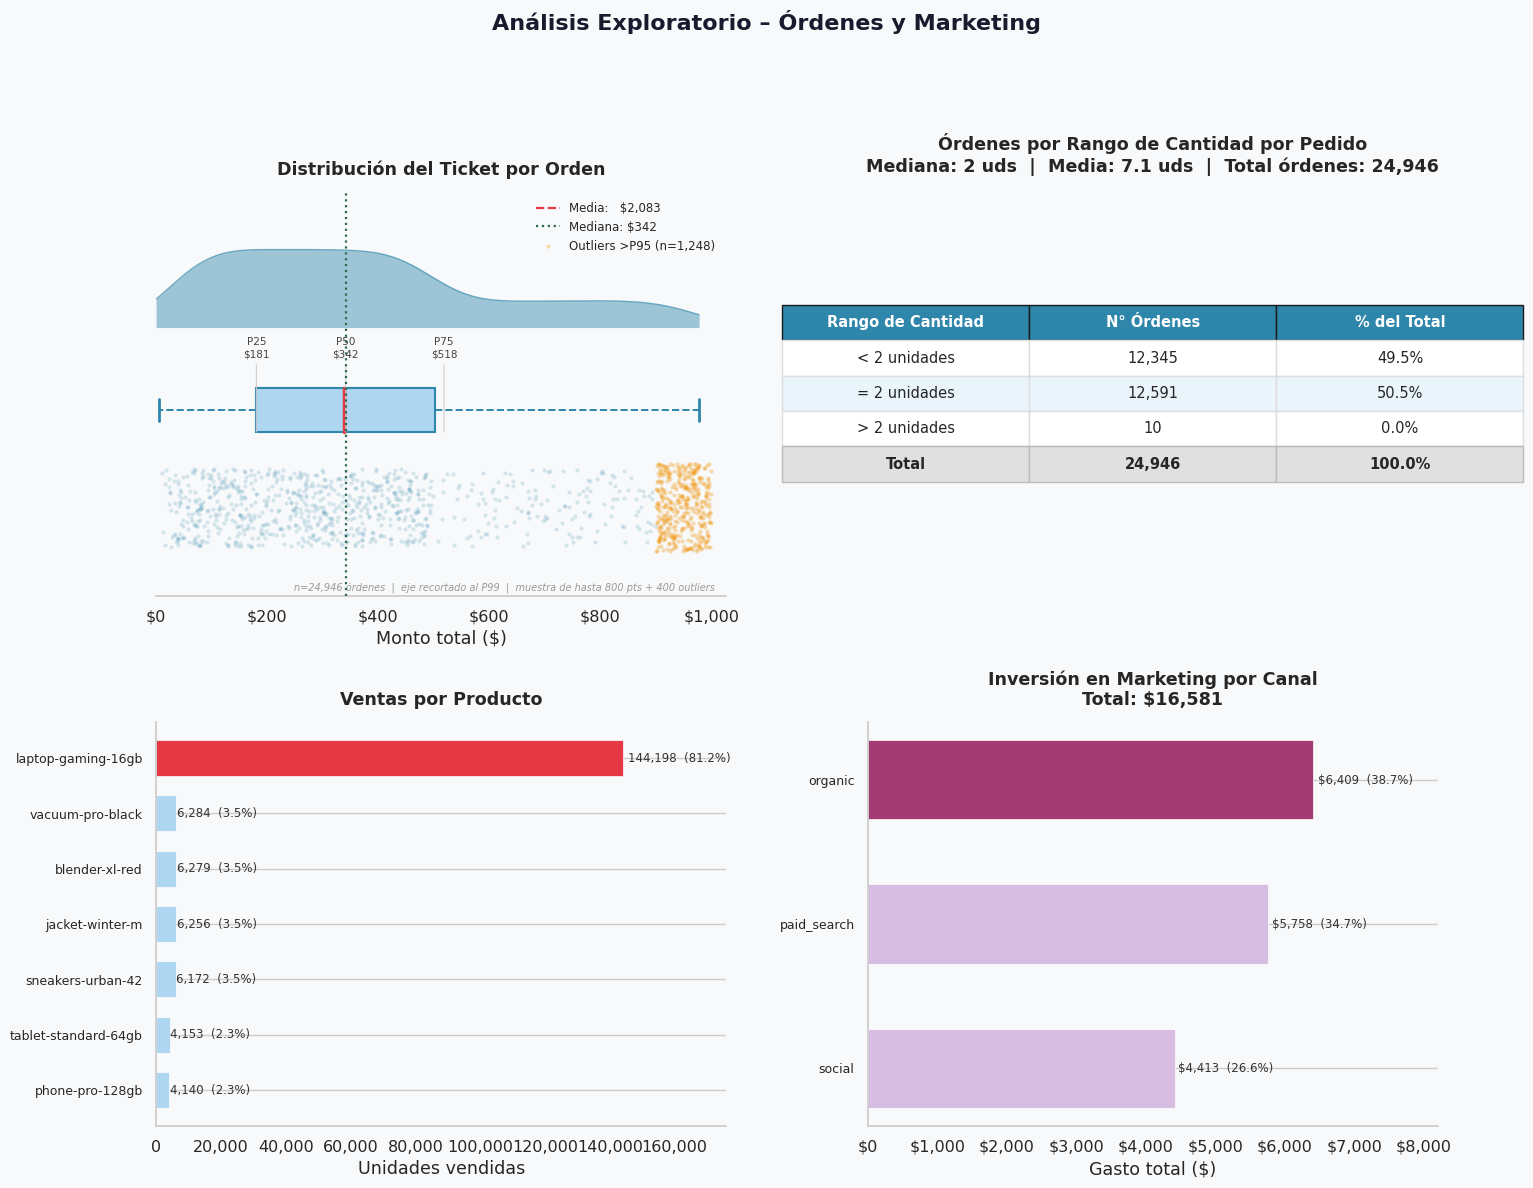

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# ── Estilo global ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
ACCENT   = '#2E86AB'
MED_CLR  = '#E63946'
GREEN    = '#2d6a4f'
PURPLE   = '#A23B72'
PURPLE_L = '#D7BDE2'
BG       = '#f8f9fa'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Exploratorio – Órdenes y Marketing',
             fontsize=16, fontweight='bold', y=1.01, color='#1a1a2e')
fig.patch.set_facecolor(BG)
for ax in axes.flat:
    ax.set_facecolor(BG)

def remove_spines(ax, keep=('bottom',)):
    for s in ax.spines:
        ax.spines[s].set_visible(s in keep)

# ══════════════════════════════════════════════════════════════════════════════
# 1. Ticket por orden → Raincloud plot
# ══════════════════════════════════════════════════════════════════════════════
ticket_por_orden = orders.groupby('id_pedido')['monto_total'].sum()
ticket_promedio  = ticket_por_orden.mean()
ticket_mediana   = ticket_por_orden.median()
ticket_p25       = ticket_por_orden.quantile(0.25)
ticket_p75       = ticket_por_orden.quantile(0.75)
ticket_p95       = ticket_por_orden.quantile(0.95)
ticket_p99       = ticket_por_orden.quantile(0.99)
kde_data         = ticket_por_orden.values
n                = len(kde_data)

ax1 = axes[0, 0]
np.random.seed(42)

# KDE solo con datos ≤ P99
datos_kde = kde_data[kde_data <= ticket_p99]
kde_fn    = gaussian_kde(datos_kde, bw_method=0.25)
x_range   = np.linspace(0, ticket_p99, 400)
y_kde     = kde_fn(x_range)
y_kde     = y_kde / y_kde.max() * 0.16

ax1.fill_between(x_range, 0.60, 0.60 + y_kde, color=ACCENT, alpha=0.45, linewidth=0)
ax1.plot(x_range, 0.60 + y_kde, color=ACCENT, linewidth=1.0, alpha=0.7)

# Boxplot (sin fliers — los mostramos en scatter)
ax1.boxplot(datos_kde, vert=False, positions=[0.43], widths=0.09,
            patch_artist=True,
            boxprops    =dict(facecolor='#AED6F1', color=ACCENT, linewidth=1.5),
            medianprops =dict(color=MED_CLR, linewidth=2.5),
            whiskerprops=dict(color=ACCENT, linewidth=1.4, linestyle='--'),
            capprops    =dict(color=ACCENT, linewidth=2),
            flierprops  =dict(marker=''),
            manage_ticks=False)

# Scatter puntos normales (≤ P95)
datos_norm  = kde_data[kde_data <= ticket_p95]
muestra_n   = np.random.choice(datos_norm, min(800, len(datos_norm)), replace=False)
jitter_n    = np.random.uniform(-0.08, 0.08, size=len(muestra_n))
ax1.scatter(muestra_n, 0.23 + jitter_n,
            c=ACCENT, alpha=0.18, s=9, linewidths=0, zorder=3)

# Scatter outliers (> P95) con jitter amplio para que no se apilen
outliers    = kde_data[kde_data > ticket_p95]
n_out       = len(outliers)
muestra_out = np.random.choice(outliers, min(400, n_out), replace=False)
# Jitter vertical más amplio + aleatorizar también posición horizontal ligeramente
jitter_out  = np.random.uniform(-0.09, 0.09, size=len(muestra_out))
ax1.scatter(muestra_out, 0.23 + jitter_out,
            c='#F18F01', alpha=0.30, s=9, linewidths=0,
            zorder=4, label=f'Outliers >P95 (n={n_out:,})')

# Líneas de referencia
ax1.axvline(ticket_promedio, color=MED_CLR, linestyle='--',
            linewidth=1.6, zorder=5, label=f'Media:   ${ticket_promedio:,.0f}')
ax1.axvline(ticket_mediana, color=GREEN, linestyle=':',
            linewidth=1.6, zorder=5, label=f'Mediana: ${ticket_mediana:,.0f}')

# Anotaciones P25 / P50 / P75
for val, lbl in [(ticket_p25, 'P25'), (ticket_mediana, 'P50'), (ticket_p75, 'P75')]:
    ax1.annotate(f'{lbl}\n${val:,.0f}',
                 xy=(val, 0.38), xytext=(val, 0.54),
                 fontsize=7.5, ha='center', color='#444',
                 arrowprops=dict(arrowstyle='-', color='#ccc', lw=0.8))

ax1.set_xlim(left=0, right=ticket_p99 * 1.05)
ax1.set_ylim(0.05, 0.88)
ax1.set_yticks([])
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_title('Distribución del Ticket por Orden', fontweight='bold', pad=12)
ax1.set_xlabel('Monto total ($)')
ax1.legend(fontsize=8.5, frameon=False, loc='upper right')
remove_spines(ax1)
ax1.grid(axis='x', alpha=0.3)
ax1.text(0.98, 0.01,
         f'n={n:,} órdenes  |  eje recortado al P99  |  muestra de hasta 800 pts + 400 outliers',
         transform=ax1.transAxes, fontsize=7, color='#999', ha='right', style='italic')

# ══════════════════════════════════════════════════════════════════════════════
# 2. Cantidad por orden → Tabla
# ══════════════════════════════════════════════════════════════════════════════
qty_por_orden     = orders.groupby('id_pedido')['cantidad'].sum()
cantidad_mediana  = qty_por_orden.median()
cantidad_promedio = qty_por_orden.mean()
total_ordenes     = len(qty_por_orden)

cnt_menor = (qty_por_orden < 2).sum()
cnt_igual = (qty_por_orden == 2).sum()
cnt_mayor = (qty_por_orden > 2).sum()

tabla_data  = [
    ['< 2 unidades', f'{cnt_menor:,}', f'{cnt_menor/total_ordenes*100:.1f}%'],
    ['= 2 unidades', f'{cnt_igual:,}', f'{cnt_igual/total_ordenes*100:.1f}%'],
    ['> 2 unidades', f'{cnt_mayor:,}', f'{cnt_mayor/total_ordenes*100:.1f}%'],
    ['Total',        f'{total_ordenes:,}', '100.0%'],
]
col_headers = ['Rango de Cantidad', 'N° Órdenes', '% del Total']

ax2 = axes[0, 1]
ax2.axis('off')

tabla = ax2.table(cellText=tabla_data, colLabels=col_headers,
                  cellLoc='center', loc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(10.5)
tabla.scale(1.3, 2.2)

# Encabezado
for col in range(len(col_headers)):
    tabla[0, col].set_facecolor(ACCENT)
    tabla[0, col].set_text_props(color='white', fontweight='bold')

# Filas alternas
for row in range(1, len(tabla_data)):          # sin fila total
    color = '#EAF4FB' if row % 2 == 0 else 'white'
    for col in range(len(col_headers)):
        tabla[row, col].set_facecolor(color)
        tabla[row, col].set_edgecolor('#dddddd')

# Fila total en gris
for col in range(len(col_headers)):
    tabla[len(tabla_data), col].set_facecolor('#e0e0e0')
    tabla[len(tabla_data), col].set_text_props(fontweight='bold')
    tabla[len(tabla_data), col].set_edgecolor('#bbbbbb')

ax2.set_title(
    f'Órdenes por Rango de Cantidad por Pedido\n'
    f'Mediana: {int(cantidad_mediana)} uds  |  Media: {cantidad_promedio:,.1f} uds  |  '
    f'Total órdenes: {total_ordenes:,}',
    fontweight='bold', pad=14
)

# ══════════════════════════════════════════════════════════════════════════════
# 3. Top productos → producto dominante separado + resto escalado
# ══════════════════════════════════════════════════════════════════════════════
top_productos = (orders.groupby('nombre_producto')['cantidad']
                       .sum().sort_values(ascending=False))
total_uds = orders['cantidad'].sum()

ax3 = axes[1, 0]

colores3 = ['#E63946'] + ['#AED6F1'] * (len(top_productos) - 1)
ax3.barh(top_productos.index[::-1], top_productos.values[::-1],
         color=colores3[::-1], edgecolor='white', linewidth=0.5, height=0.65)

for i, v in enumerate(top_productos.values[::-1]):
    ax3.text(v * 1.01, i,
             f'{v:,.0f}  ({v/total_uds*100:.1f}%)',
             va='center', fontsize=8.5, color='#333')

ax3.set_title('Ventas por Producto', fontweight='bold', pad=12)
ax3.set_xlabel('Unidades vendidas')
ax3.margins(x=0.22)
ax3.tick_params(axis='y', labelsize=9)
remove_spines(ax3, keep=('bottom', 'left'))
ax3.grid(axis='x', alpha=0.3)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ══════════════════════════════════════════════════════════════════════════════
# 4. Marketing por canal → Barh + % del total
# ══════════════════════════════════════════════════════════════════════════════
marketing_por_canal = (marketing.groupby('canal')['gasto']
                                .sum().sort_values(ascending=False))
total_mkt   = marketing_por_canal.sum()

ax4 = axes[1, 1]
colores4 = [PURPLE] + [PURPLE_L] * (len(marketing_por_canal) - 1)
ax4.barh(marketing_por_canal.index[::-1], marketing_por_canal.values[::-1],
         color=colores4[::-1], edgecolor='white', linewidth=0.5, height=0.55)

for i, v in enumerate(marketing_por_canal.values[::-1]):
    ax4.text(v * 1.01, i,
             f'${v:,.0f}  ({v/total_mkt*100:.1f}%)',
             va='center', fontsize=8.5, color='#333')

ax4.set_title(f'Inversión en Marketing por Canal\nTotal: ${total_mkt:,.0f}',
              fontweight='bold', pad=12)
ax4.set_xlabel('Gasto total ($)')
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax4.margins(x=0.28)
ax4.tick_params(axis='y', labelsize=9)
remove_spines(ax4, keep=('bottom', 'left'))
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout(pad=2.5)
plt.savefig('paso2_visualizaciones.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

---

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para el paso 2 lo ideal sería revisar las variables con gráficas siguiendo el objetivo del paso y lo que le interesa a la empresa revisar. Siempre una gráfica es mucho mejor que sólo mostrar valores numéricos, por ejemplo para la pregunta del ticket promedio podrías también mostrar la distribución ticket usando un histograma y así con el resto de preguntas escogiendo la visualización adecuada del aso.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Perfecto, de esta forma el proceso de análisis queda mucho más claro en cuanto al paso a paso que seguiste para anlizar cada parte de tus datos.
</div>

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [32]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [33]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()


,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [34]:
print(events.columns.tolist())
print(events.head(3))
print(events['nombre_evento'].unique())

['id_usuario', 'id_sesion', 'nombre_evento', 'timestamp_evento', 'pais', 'dispositivo', 'fuente_referencia', 'categoria_producto']
  id_usuario                             id_sesion     nombre_evento  \
0  user_6772  6a97f2af-32ae-4186-8c92-04025be1a27b       first_visit   
1  user_5883  369b767c-1c33-4b2f-a652-c7c0ef92cfc9       add_to_cart   
2  user_5946  60039041-e78b-474c-87b3-c0b7e9c30708  add_payment_info   

  timestamp_evento      pais dispositivo fuente_referencia categoria_producto  
0       2025-05-17  Colombia     desktop           organic               Moda  
1       2025-02-23    Mexico      mobile            social              Hogar  
2       2025-05-15  Colombia     desktop            social        Electronica  
['first_visit' 'add_to_cart' 'add_payment_info' 'purchase'
 'begin_checkout' 'select_item']


In [35]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS total_usuarios,
    COUNT(DISTINCT id_sesion)  AS total_sesiones
FROM events
GROUP BY nombre_evento
ORDER BY
    CASE nombre_evento
        WHEN 'first_visit'       THEN 1
        WHEN 'select_item'       THEN 2
        WHEN 'add_to_cart'       THEN 3
        WHEN 'begin_checkout'    THEN 4
        WHEN 'add_payment_info'  THEN 5
        WHEN 'purchase'          THEN 6
    END;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,total_usuarios,total_sesiones
0,first_visit,7796,29957
1,select_item,7582,23887
2,add_to_cart,7634,24157
3,begin_checkout,7208,17971
4,add_payment_info,6250,12018
5,purchase,6240,12010


In [36]:
query_conversion = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios,
    CASE nombre_evento
        WHEN 'first_visit'      THEN 1
        WHEN 'select_item'      THEN 2
        WHEN 'add_to_cart'      THEN 3
        WHEN 'begin_checkout'   THEN 4
        WHEN 'add_payment_info' THEN 5
        WHEN 'purchase'         THEN 6
    END AS orden
FROM events
GROUP BY nombre_evento
ORDER BY orden
'''

conversion = pd.read_sql(query_conversion, con=engine)

# Porcentajes calculados en pandas (más confiable)
inicio = conversion['usuarios'].iloc[0]
conversion['conversion_vs_inicio']        = (conversion['usuarios'] / inicio * 100).round(2)
conversion['conversion_vs_paso_anterior'] = (conversion['usuarios'] / conversion['usuarios'].shift(1) * 100).round(2)
conversion['usuarios_perdidos']           = conversion['usuarios'].shift(1) - conversion['usuarios']

conversion = conversion.drop(columns='orden')
conversion

,nombre_evento,usuarios,conversion_vs_inicio,conversion_vs_paso_anterior,usuarios_perdidos
0,first_visit,7796,100.00,NaN,NaN
1,select_item,7582,97.26,97.26,214.0
2,add_to_cart,7634,97.92,100.69,-52.0
3,begin_checkout,7208,92.46,94.42,426.0
4,add_payment_info,6250,80.17,86.71,958.0
5,purchase,6240,80.04,99.84,10.0


## Análisis del Funnel de Conversión

El funnel rastrea el recorrido de 7,796 usuarios únicos desde el primer contacto
hasta la compra final, con una conversión global del **80.04%**.

### Hallazgos por paso

| Paso | Observación |
|---|---|
| First visit → Select item | Caída del 2.74% (214 usuarios). El catálogo retiene bien la atención inicial. |
| Select item → Add to cart | **Anomalía:** add_to_cart supera a select_item en 52 usuarios (conversión 100.69%). Esto sugiere un problema de instrumentación — usuarios que agregan al carrito sin disparar el evento select_item. Requiere revisión del tracking. |
| Add to cart → Begin checkout | Caída del 5.58% (426 usuarios). Abandono de carrito moderado; causas típicas: costos de envío o registro obligatorio. |
| Begin checkout → Add payment info | Caída del 13.29% (958 usuarios). **Mayor punto de fuga del funnel.** Fricción alta en el proceso de pago; revisar cantidad de pasos y métodos disponibles. |
| Add payment info → Purchase | Caída del 0.16% (10 usuarios). Casi sin fricción — quien llega a este paso completa la compra. |

### Conclusión

El paso crítico a optimizar es **Begin checkout → Add payment info**, donde se
pierde el 13% de los usuarios. Adicionalmente, la anomalía en **Select item →
Add to cart** debe corregirse a nivel de tracking antes de usar estas métricas
para decisiones de negocio.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Aquí te pediría revisar la lógica en la query ya que las conversiones **totales** para cada paso deberían ir bajando en % de forma descente pero si revisas tus porcentajes no están de forma descente así que hay que ajustar la query.

También, cuando se trata de conversiones no es correcta que una de ellas tenga más de 100% ya que eso representaría un error en el cálculo o los datos.

También hace falta que redactes tu propio análisis de cada uno de los resultados que estás presentando, esto lo deberías hacer en una celda markdown.
</div>

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [17]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [18]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)


,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [42]:
# Retención por cohortes
# ======================
query_cohort_retention_final = '''
WITH cohort AS (
    SELECT
        id_usuario,
        DATE_TRUNC('month', MIN(fecha_actividad::DATE)) AS cohort_mes
    FROM user_activity
    GROUP BY id_usuario
),
actividad_mensual AS (
    SELECT
        id_usuario,
        DATE_TRUNC('month', fecha_actividad::DATE) AS mes_actividad
    FROM user_activity
    WHERE activo = 1
    GROUP BY id_usuario, DATE_TRUNC('month', fecha_actividad::DATE)
),
cohort_activity AS (
    SELECT
        c.cohort_mes,
        EXTRACT(YEAR FROM AGE(a.mes_actividad, c.cohort_mes)) * 12 +
        EXTRACT(MONTH FROM AGE(a.mes_actividad, c.cohort_mes)) AS mes_numero,
        COUNT(DISTINCT a.id_usuario) AS usuarios_activos
    FROM cohort c
    JOIN actividad_mensual a ON c.id_usuario = a.id_usuario
    GROUP BY c.cohort_mes, mes_numero
),
cohort_size AS (
    SELECT cohort_mes, COUNT(DISTINCT id_usuario) AS total_usuarios
    FROM cohort
    GROUP BY cohort_mes
)
SELECT
    ca.cohort_mes,
    ca.mes_numero,
    ca.usuarios_activos,
    cs.total_usuarios,
    ROUND(ca.usuarios_activos * 100.0 / cs.total_usuarios, 2) AS retencion_pct
FROM cohort_activity ca
JOIN cohort_size cs ON ca.cohort_mes = cs.cohort_mes
WHERE ca.mes_numero >= 0
ORDER BY ca.cohort_mes, ca.mes_numero
'''
# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohort_mes,mes_numero,usuarios_activos,total_usuarios,retencion_pct
0,2025-01-01 00:00:00+00:00,0.0,777,1239,62.71
1,2025-01-01 00:00:00+00:00,1.0,675,1239,54.48
2,2025-02-01 00:00:00+00:00,0.0,1037,1492,69.50
3,2025-02-01 00:00:00+00:00,1.0,682,1492,45.71
4,2025-03-01 00:00:00+00:00,0.0,1122,1625,69.05
5,2025-03-01 00:00:00+00:00,1.0,710,1625,43.69
6,2025-04-01 00:00:00+00:00,0.0,1078,1563,68.97
7,2025-04-01 00:00:00+00:00,1.0,692,1563,44.27
8,2025-05-01 00:00:00+00:00,0.0,1152,1693,68.04
9,2025-05-01 00:00:00+00:00,1.0,690,1693,40.76


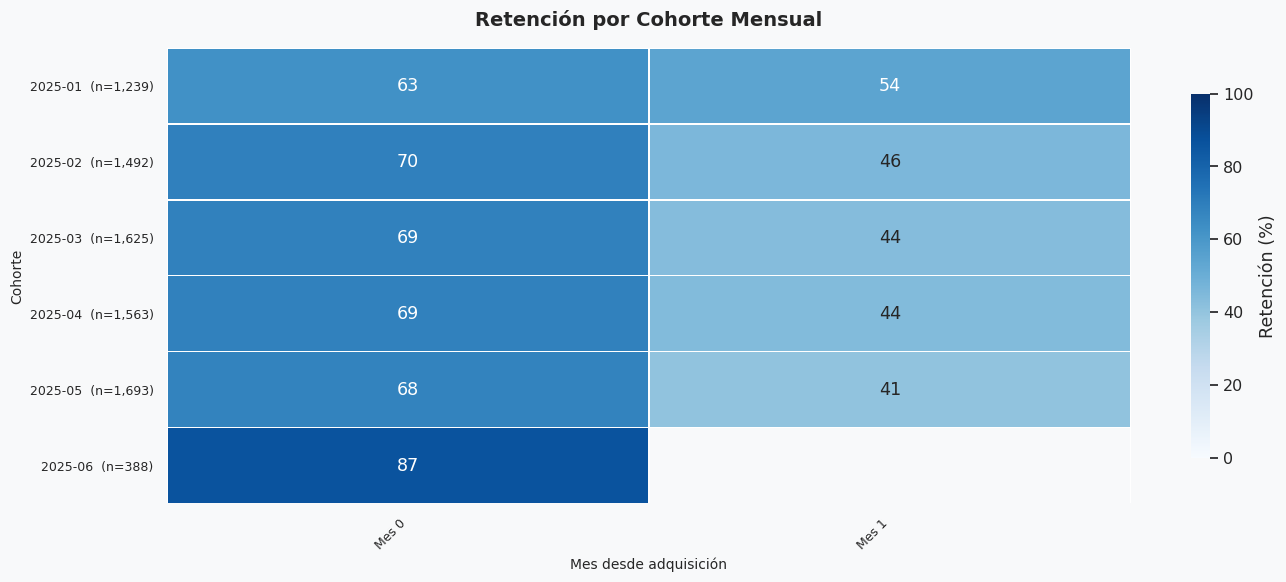

In [45]:
# Pivot para heatmap
cohort_pivot = cohorte_final.pivot(index='cohort_mes', columns='mes_numero', values='retencion_pct')
cohort_pivot.index = cohort_pivot.index.strftime('%Y-%m')

# Tamaño de cada cohorte para anotarlo
cohort_sizes = cohorte_final.drop_duplicates('cohort_mes').set_index('cohort_mes')['total_usuarios']
cohort_sizes.index = cohort_sizes.index.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.4,
    linecolor='white',
    vmin=0, vmax=100,
    ax=ax,
    cbar_kws={'label': 'Retención (%)', 'shrink': 0.8}
)

# Etiquetas eje Y con tamaño de cohorte
nuevas_etiquetas = [f"{mes}  (n={cohort_sizes[mes]:,})" for mes in cohort_pivot.index]
ax.set_yticklabels(nuevas_etiquetas, rotation=0, fontsize=9)
ax.set_xticklabels([f'Mes {int(c)}' for c in cohort_pivot.columns], rotation=45, ha='right', fontsize=9)

ax.set_title('Retención por Cohorte Mensual', fontsize=14, fontweight='bold', pad=16)
ax.set_xlabel('Mes desde adquisición', fontsize=10)
ax.set_ylabel('Cohorte', fontsize=10)

plt.tight_layout()
plt.savefig('cohort_retention.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

---

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Perfecto la query y los resultados presentados. Lo único que recomendaría aquí es tratar de llevarlo a algo más visual para que sea más fácil de explicar y entender
</div>

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  


Hipótesis estadística

* H₀ (Hipótesis nula): La tasa de conversión del grupo control es igual a la del grupo tratamiento. El cambio en la UI del checkout no tiene efecto.
* H₁ (Hipótesis alternativa): La tasa de conversión del grupo control es diferente a la del grupo tratamiento. El cambio en la UI del checkout sí tiene efecto.

Test estadístico: Z-test de proporciones (dos colas), elegido porque la variable de respuesta es binaria (convirtió: 0/1), los grupos son independientes y las muestras son suficientemente grandes.

Nivel de significancia: alpha = 0.05

In [20]:
import pandas as pd
experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
print(experiment.columns.tolist())
print(experiment.head(3))


['id_usuario', 'variante', 'convirtio', 'dispositivo', 'pais', 'duracion_sesion', 'timestamp']
   id_usuario     variante  convirtio dispositivo       pais  duracion_sesion  \
0  exp_user_0  tratamiento          0      mobile  Argentina           114.41   
1  exp_user_1  tratamiento          0     desktop     Mexico           170.03   
2  exp_user_2      control          1      mobile   Colombia           140.21   

    timestamp  
0  2025-03-28  
1  2025-01-15  
2  2025-03-18  


In [21]:
from scipy import stats
import numpy as np

# === 1. MÉTRICA PRINCIPAL ===
control    = experiment[experiment['variante'] == 'control']['convirtio']
tratamiento = experiment[experiment['variante'] == 'tratamiento']['convirtio']

conv_control     = control.mean()
conv_tratamiento = tratamiento.mean()

print(f"Conversión control:     {conv_control:.4f} ({conv_control*100:.2f}%)")
print(f"Conversión tratamiento: {conv_tratamiento:.4f} ({conv_tratamiento*100:.2f}%)")
print(f"Diferencia:             {(conv_tratamiento - conv_control)*100:.2f}pp")

# === 2. HIPÓTESIS ===
# H0: conv_control == conv_tratamiento (el cambio en UI no tiene efecto)
# H1: conv_control != conv_tratamiento (el cambio en UI sí tiene efecto)

# === 3. TEST ESTADÍSTICO (Z-test de proporciones) ===
n_control     = len(control)
n_tratamiento = len(tratamiento)

count = np.array([control.sum(), tratamiento.sum()])
nobs  = np.array([n_control, n_tratamiento])

from statsmodels.stats.proportion import proportions_ztest
z_stat, p_value = proportions_ztest(count, nobs)

alpha = 0.05
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

# === 4. INTERPRETACIÓN ===
print(f"\n{'='*40}")
if p_value < alpha:
    print(f"✅ Resultado SIGNIFICATIVO (p={p_value:.4f} < {alpha})")
    print("Rechazamos H0: el cambio en UI SÍ impacta la conversión.")
    if conv_tratamiento > conv_control:
        print("El tratamiento MEJORA la tasa de conversión.")
    else:
        print("El tratamiento EMPEORA la tasa de conversión.")
else:
    print(f"❌ Resultado NO significativo (p={p_value:.4f} >= {alpha})")
    print("No rechazamos H0: no hay evidencia de impacto en la conversión.")
print(f"{'='*40}")

Conversión control:     0.1569 (15.69%)
Conversión tratamiento: 0.1629 (16.29%)
Diferencia:             0.60pp

Z-statistic: -0.8133
P-value:     0.4161

❌ Resultado NO significativo (p=0.4161 >= 0.05)
No rechazamos H0: no hay evidencia de impacto en la conversión.


In [22]:
# Tamaño del efecto (Cohen's h)
from statsmodels.stats.proportion import proportion_effectsize
effect_size = proportion_effectsize(conv_tratamiento, conv_control)
print(f"Tamaño del efecto (Cohen's h): {effect_size:.4f}")
print("Interpretación: <0.2 pequeño | 0.2-0.5 mediano | >0.5 grande")

Tamaño del efecto (Cohen's h): 0.0163
Interpretación: <0.2 pequeño | 0.2-0.5 mediano | >0.5 grande


---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

https://drive.google.com/drive/folders/14Xlfw8Ee1aKzzKYU1tbqQhaG0woLcyJD?usp=sharing



<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes un muy buen avance de tu proyecto en cuanto a código Santiago, pero hace falta la parte de story telling que cómo profesional de datos siempre se debe tener. Es decir, usando celdas markdown se debe ir redactando el análisis que vas realizando de los diferentes resultados y de esta forma comunicar de manera adecuada que es lo que se está analizando y por qué.

También, al final deberías tener una sección con conclusiones y recomendaciones generales que puedas darle a la empresa en base a los diferentes pasos realizados a lo largo de tu notebook.

Si tienes dudas o dificultades recuerda que puedes contactar a tu Success Manager o a tu tutor para solventarlas.

Saludos!
</div>

<div class="alert alert-block alert-success">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado Santiago!** 

El paso a paso seguido en el proceso de análisis del proyecto quedó super claro y se ajusta a las necesidades del negocio presentadas. Recuerda que un buen análisis siempre debe tener una buena parte técnica que ayude a comprender la parte de negocio y los beneficios del mismo.<!--  -->

Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>